# Sprint 1 – Data Understanding & Preparation


## Sprint Goal


### Convert the raw flight operations dataset into a clean, structured, and analysis-ready dataset.


# Tasks

#  1. Business Understanding


### Understand the problem statement.


### Identify:


## ▸Business Objective


### The airline is experiencing increasing customer complaints because of flight delays and cancellations.

### The management wants to understand:

#### 1.What factors contribute to flight delays?
#### 2.Which airlines experience more delays?
#### 3.Which airports/routes have operational problems?
#### 4.What are the major causes of delays?
#### 5.What factors are associated with cancellations?
#### 6.How can the airline reduce delays and improve customer satisfaction?

## ▸Expected Outcome

### At the end of the complete project, we should be able to:

#### 1.Identify major factors affecting flight delays.
#### 2.Identify patterns in flight cancellations.
#### 3.Detect operational inefficiencies.
#### 4.Understand airline and airport performance.
#### 5.Validate important findings statistically.
#### 5.Create meaningful features for deeper analysis.
#### 6.Provide actionable recommendations to airline management.

# 2. Dataset Understanding


### Study the dataset carefully.


### Determine:


## ▸Number of rows



In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("Flight_Delays_50K.csv")

In [7]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,5,14,4,US,1721,N174US,CLT,SMF,1810,...,2043.0,4.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,11,29,7,MQ,3363,N902MQ,LEX,ORD,1837,...,1942.0,17.0,0,0,NaN,0.0,0.0,0.0,17.0,0.0
2,2015,2,10,2,US,1933,N562UW,PHL,ORD,730,...,834.0,-28.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,12,21,1,UA,1929,N460UA,SEA,EWR,622,...,1414.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,5,7,4,DL,1478,N67171,ATL,PHL,725,...,920.0,-5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.shape[0]

50000

### •Number of Rows
#### 1.The dataset contains 50,000 rows.
#### 2.Each row represents one flight operation record. Therefore, the dataset contains information about 50,000 individual flight records.
### •Observation
#### The dataset consists of 50,000 flight records, providing a sufficiently large number of observations for further data cleaning, exploratory 

#### analysis, statistical analysis, and business insights.

## ▸Number of columns

In [9]:
df.shape[1]

31

### •Number of Columns
#### 1.The dataset contains 31 columns.
#### 2.Each column represents a specific feature or attribute related to flight operations, such as airline information, airport details, scheduled 

#### and actual timings, delays, cancellations,and delay causes.
### •Observation
#### The dataset contains 31 features, which provide information about different aspects of flight operations. These features will be examined

#### further to understand their data types and relevance to the business problem.

## ▸Features available


In [10]:
df.columns.tolist()

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

### •Features Available
#### The dataset contains 31 features covering flight schedules,airline information, airport information, actual flightoperations, delays,
#### cancellations, and different causes of flight delays.
### •The features can broadly be categorized into:
#### 1. Flight and airline information
#### 2. Date and time information
#### 3. Airport information
#### 4. Flight operation information
#### 5. Delay information
#### 6. Cancellation information
#### 7. Delay cause information
#### These features provide the necessary information to analyze flight delays, cancellations, and operational efficiency.

## ▸Target variable (Delay Status / Arrival Delay)


In [11]:
df['ARRIVAL_DELAY'].head()

0     4.0
1    17.0
2   -28.0
3   -17.0
4    -5.0
Name: ARRIVAL_DELAY, dtype: float64

In [12]:
df['ARRIVAL_DELAY'].dtype

dtype('float64')

#### *Why ARRIVAL_DELAY?

#### ARRIVAL_DELAY represents the difference between the scheduled arrival time and the actual arrival time, measured in minutes.

### •Target Variable
#### 1.The primary target variable for this project is 'ARRIVAL_DELAY'.
#### 2.The dataset does not contain a separate 'Delay Status' column.Therefore, 'ARRIVAL_DELAY' is considered the primary target variable for 
#### analyzing flight delays.
#### 3.'ARRIVAL_DELAY' represents the difference between the scheduled arrival time and the actual arrival time in minutes.
#### 4.Positive values indicate that the flight arrived late, zero indicates an on-time arrival, and negative values indicate that the flight arrived 

#### earlier than scheduled.
#### 5.The 'CANCELLED' variable will also be considered separately when analyzing flight cancellations.

#### -->Primary Target Variable: ARRIVAL_DELAY
#### -->Secondary business outcome: CANCELLED
#### -->And later, if needed, we can create a DELAY_STATUS feature during feature engineering, but we don't need to create it now.

## ▸Numerical columns


#### A numerical column is a column that contains numeric values and can generally be used for mathematical or statistical calculations.

#### *In our Flight Delay dataset, examples include:
#### 1.YEAR
#### 2.MONTH
#### 3.DEPARTURE_DELAY
#### 4.ARRIVAL_DELAY
#### 5.DISTANCE
#### 6.AIR_TIME

### Step 1 — Identify numerical columns

In [13]:
import numpy as np

In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

In [15]:
numerical_columns

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'FLIGHT_NUMBER',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

#### This will give you the exact numerical columns detected by Pandas.

### Step 2 — Count them

In [16]:
len(numerical_columns)

26

### Step 3 — Display them with numbers

In [17]:
for i, column in enumerate(numerical_columns, 1):
    print(i, column)

1 YEAR
2 MONTH
3 DAY
4 DAY_OF_WEEK
5 FLIGHT_NUMBER
6 SCHEDULED_DEPARTURE
7 DEPARTURE_TIME
8 DEPARTURE_DELAY
9 TAXI_OUT
10 WHEELS_OFF
11 SCHEDULED_TIME
12 ELAPSED_TIME
13 AIR_TIME
14 DISTANCE
15 WHEELS_ON
16 TAXI_IN
17 SCHEDULED_ARRIVAL
18 ARRIVAL_TIME
19 ARRIVAL_DELAY
20 DIVERTED
21 CANCELLED
22 AIR_SYSTEM_DELAY
23 SECURITY_DELAY
24 AIRLINE_DELAY
25 LATE_AIRCRAFT_DELAY
26 WEATHER_DELAY


### •Numerical Columns
#### The dataset contains 26 numerical columns. These columns represent numerical information related to flight dates,scheduled and actual 

#### timings,departure and arrival delays,flight duration, distance, cancellation and diversion status,and different causes of flight delays.
#### The numerical columns were identified using the Pandas 'select_dtypes()' function based on their data types.

### •Observation
#### There are 26 numerical features in the dataset. These features provide quantitative information that can be used for statistical analysis 
####  and further exploration of flight operations and delays.

### •Some columns are stored as numbers but are actually categorical/indicator variables from a business perspective.
#### For example:
#### 1.DIVERTED
#### 2.CANCELLED
### usually contain values such as 0 and 1.
#### They are numerical in the DataFrame's technical data type, but they represent categories:
#### 0 → No
#### 1 → Yes
#### For Dataset Understanding, we'll report them as numerical because Pandas detects them as numeric. Later, during EDA, we'll treat 

#### them appropriately based on their business meaning.

## ▸Categorical columns


#### Categorical columns contain labels, names, or categories rather than continuous numerical measurements.

### Step 1 — Identify categorical columns

In [18]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

In [19]:
categorical_columns

['AIRLINE',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'CANCELLATION_REASON']

### Step 2 — Count them

In [20]:
for i, column in enumerate(categorical_columns, 1):
    print(i, column)

1 AIRLINE
2 TAIL_NUMBER
3 ORIGIN_AIRPORT
4 DESTINATION_AIRPORT
5 CANCELLATION_REASON


### •Categorical Columns
#### 1.The dataset contains 5 categorical columns.
#### 2.These columns represent qualitative information such as airline,aircraft identification, origin airport, destination airport,and cancellation 

#### reason.
#### 3.The categorical columns were identified using Pandas based on their object data type.

### •Observation
#### The categorical features provide information about the airline,aircraft, airports, and cancellation reasons. These variables will be useful for 
#### comparing flight delays and cancellations across different categories.

### Final conclusion for Dataset Understanding
#### 1.The Flight Delay dataset contains 50,000 flight records and 31 features. The primary target variable is 'ARRIVAL_DELAY',which represents 

####  arrival delay in minutes.
#### 2.Based on the DataFrame data types, the dataset contains 26 numerical columns and 5 categorical columns. The features cover flight 

#### details, airline and airport information, scheduled and actual flight timings, delays, cancellations, and different delay causes.
#### 3.The dataset provides sufficient information to proceed with further exploration and data preparation.

# 3. DataFrame Exploration


## Perform:

### ▸Shape analysis

### What is Shape Analysis?

#### Shape analysis means checking the number of rows and columns in our DataFrame.

In [21]:
df.shape

(50000, 31)

### •Shape Analysis
#### 1.The shape of the DataFrame was examined using the 'shape' attribute.
#### 2.The dataset contains 50,000 rows and 31 columns.
#### 3.Each row represents an individual flight operation record,while each column represents a feature related to the flight.
#### 4.Therefore, the dataset has a total of 50,000 observations and 31 variables.

### •Observation
#### The dataset contains 50,000 flight records and 31 features,providing a substantial number of observations for furtherdata exploration,  

#### cleaning,statistical analysis,andvisualization.

### ▸Data types

### What are data types?

#### Data types tell us what kind of data each column contains.

### Step 1 — Check data types

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv("Flight_Delays_50K.csv")

In [23]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,5,14,4,US,1721,N174US,CLT,SMF,1810,...,2043.0,4.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,11,29,7,MQ,3363,N902MQ,LEX,ORD,1837,...,1942.0,17.0,0,0,NaN,0.0,0.0,0.0,17.0,0.0
2,2015,2,10,2,US,1933,N562UW,PHL,ORD,730,...,834.0,-28.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,12,21,1,UA,1929,N460UA,SEA,EWR,622,...,1414.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,5,7,4,DL,1478,N67171,ATL,PHL,725,...,920.0,-5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

In [25]:
df.dtypes.value_counts()

float64    16
int64      10
object      5
Name: count, dtype: int64

### •Data Types

#### 1.The data types of all columns were examined using the 'dtypes' attribute of the Pandas DataFrame.
#### 2.The dataset contains numerical and categorical variables.
#### 3.Numerical variables are stored mainly as integer (`int64`) and floating-point (`float64`) data types, while categorical variables are  

#### stored as object ('object') data types.
#### 4.Checking data types is important because incorrect data types can affect calculations, analysis, visualization, and further data cleaning 

#### operations.

### •Observation

#### After running df.dtypes, look specifically for:
#### int64 → integer values
#### float64 → decimal/numerical values
#### object → text/categorical values
#### •The DataFrame contains integer, floating-point, and object data types. The data types will be reviewed during the 

#### data cleaning stage to identify any columns that may require conversion or correction.

## ▸Column information


### What is column information?

#### Column information helps us understand the overall structure of every column, including:
#### 1.Column name
#### 2.Number of non-null values
#### 3.Data type
#### 4.Memory usage
#### This is especially useful before data cleaning, because it can help us identify columns containing missing values.

### Step 1 — Run df.info()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YEAR                 50000 non-null  int64  
 1   MONTH                50000 non-null  int64  
 2   DAY                  50000 non-null  int64  
 3   DAY_OF_WEEK          50000 non-null  int64  
 4   AIRLINE              50000 non-null  object 
 5   FLIGHT_NUMBER        50000 non-null  int64  
 6   TAIL_NUMBER          49871 non-null  object 
 7   ORIGIN_AIRPORT       50000 non-null  object 
 8   DESTINATION_AIRPORT  50000 non-null  object 
 9   SCHEDULED_DEPARTURE  50000 non-null  int64  
 10  DEPARTURE_TIME       49234 non-null  float64
 11  DEPARTURE_DELAY      49234 non-null  float64
 12  TAXI_OUT             49215 non-null  float64
 13  WHEELS_OFF           49215 non-null  float64
 14  SCHEDULED_TIME       50000 non-null  float64
 15  ELAPSED_TIME         49085 non-null 

### •Column Information

#### 1.The 'info()' function was used to examine the structure of the Flight Delay dataset.
#### 2.The dataset contains 50,000 entries and 31 columns. Among the 31 columns, 10 columns have an 'int64' data type, 16 columnshave a 
#### 'float64' data type, and 5 columns have an 'object' data type.
#### 3.The non-null counts indicate that several columns contain missing values. Missing values are observed in flight timing,delay, aircraft,
#### cancellation reason, and delay-cause features.
#### 4.The 'CANCELLATION_REASON' column contains a large number of missing values, while the delay-cause columns also contain many 
#### missing values. These missing values will be investigated and handled during the Data Cleaning stage based on their business meaning 
#### rather than being removed blindly.
#### 5.The DataFrame uses approximately 11.8 MB of memory.

### •Observation

#### The dataset contains a mixture of numerical and categorical features. Several columns contain missing values, particularly cancellation 
#### reasons and delay-cause variables. These missing values require further investigation to determine whether they represent actual missing
#### data or meaningful conditions such as flights that were not cancelled or flights that did not experience a particular type of delay.

## ▸Summary statistics


### What are Summary Statistics?

#### Summary statistics provide a quick overview of the numerical data, including:
#### Count
#### Mean (Average)
#### Standard Deviation
#### Minimum Value
#### 25th Percentile
#### 50th Percentile (Median)
#### 75th Percentile
#### Maximum Value
#### These statistics help us understand the distribution and spread of the data.

In [27]:
import pandas as pd
df = pd.read_csv("Flight_Delays_50K.csv")

In [28]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,50000.0,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,49234.000000,49234.000000,49215.000000,49215.000000,...,50000.00000,49182.000000,49085.00000,50000.000000,50000.000000,9100.000000,9100.000000,9100.000000,9100.000000,9100.000000
mean,2015.0,6.543440,15.68610,3.941880,2177.016720,1326.620920,1330.928728,9.086526,16.019344,1352.902387,...,1489.85644,1473.280631,3.99945,0.002420,0.015880,13.232418,0.071429,18.419121,22.633736,2.905604
std,0.0,3.395736,8.77768,1.992019,1759.888911,483.235737,496.210684,35.464728,8.805555,497.512045,...,505.73494,523.907408,37.75498,0.049134,0.125013,26.820545,1.793296,45.155575,41.287011,19.951584
min,2015.0,1.000000,1.00000,1.000000,1.000000,3.000000,1.000000,-55.000000,1.000000,1.000000,...,1.00000,1.000000,-70.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,4.000000,8.00000,2.000000,733.000000,915.000000,919.000000,-5.000000,11.000000,933.000000,...,1108.00000,1056.000000,-13.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,7.000000,16.00000,4.000000,1686.000000,1324.000000,1327.000000,-2.000000,14.000000,1340.000000,...,1518.00000,1510.000000,-5.00000,0.000000,0.000000,2.000000,0.000000,2.000000,3.000000,0.000000
75%,2015.0,9.000000,23.00000,6.000000,3246.000000,1730.000000,1737.000000,7.000000,19.000000,1751.000000,...,1915.00000,1913.000000,8.00000,0.000000,0.000000,18.000000,0.000000,19.000000,28.000000,0.000000
max,2015.0,12.000000,31.00000,7.000000,8410.000000,2359.000000,2400.000000,1515.000000,149.000000,2400.000000,...,2359.00000,2400.000000,1574.00000,1.000000,1.000000,532.000000,129.000000,1515.000000,765.000000,510.000000


In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,50000.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,50000.0,6.543440,3.395736,1.0,4.0,7.0,9.0,12.0
DAY,50000.0,15.686100,8.777680,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,50000.0,3.941880,1.992019,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,50000.0,2177.016720,1759.888911,1.0,733.0,1686.0,3246.0,8410.0
SCHEDULED_DEPARTURE,50000.0,1326.620920,483.235737,3.0,915.0,1324.0,1730.0,2359.0
DEPARTURE_TIME,49234.0,1330.928728,496.210684,1.0,919.0,1327.0,1737.0,2400.0
DEPARTURE_DELAY,49234.0,9.086526,35.464728,-55.0,-5.0,-2.0,7.0,1515.0
TAXI_OUT,49215.0,16.019344,8.805555,1.0,11.0,14.0,19.0,149.0
WHEELS_OFF,49215.0,1352.902387,497.512045,1.0,933.0,1340.0,1751.0,2400.0


### •Summary Statistics

#### 1.Summary statistics were generated using the 'describe()'function.
#### 2.The output provides key statistical measures such as count,mean, standard deviation, minimum value, maximum value, and quartiles for 
#### all numerical variables.
#### 3.These statistics help understand the distribution of flight operations data and identify potential anomalies or outliers that may require 
#### further investigation.

### •Observation
#### The summary statistics provide an overview of the numerical features in the dataset. The results will be used to identify potential outliers, 

#### understand data distributions, and supportfurther data cleaning and exploratory analysis.

 # 4. Data Cleaning


## ▸Missing values


### Step 1 — Check total missing values

In [30]:
df.isnull().sum()

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE                    0
FLIGHT_NUMBER              0
TAIL_NUMBER              129
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME           766
DEPARTURE_DELAY          766
TAXI_OUT                 785
WHEELS_OFF               785
SCHEDULED_TIME             0
ELAPSED_TIME             915
AIR_TIME                 915
DISTANCE                   0
WHEELS_ON                818
TAXI_IN                  818
SCHEDULED_ARRIVAL          0
ARRIVAL_TIME             818
ARRIVAL_DELAY            915
DIVERTED                   0
CANCELLED                  0
CANCELLATION_REASON    49206
AIR_SYSTEM_DELAY       40900
SECURITY_DELAY         40900
AIRLINE_DELAY          40900
LATE_AIRCRAFT_DELAY    40900
WEATHER_DELAY          40900
dtype: int64

### Step 2 — Check missing-value percentage

In [31]:
missing_count = df.isnull().sum()

missing_percentage = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage': missing_percentage
})

missing_report

,Missing Values,Missing Percentage
YEAR,0,0.000
MONTH,0,0.000
DAY,0,0.000
DAY_OF_WEEK,0,0.000
AIRLINE,0,0.000
FLIGHT_NUMBER,0,0.000
TAIL_NUMBER,129,0.258
ORIGIN_AIRPORT,0,0.000
DESTINATION_AIRPORT,0,0.000
SCHEDULED_DEPARTURE,0,0.000


In [32]:
missing_report = missing_report.sort_values(
    by='Missing Values',
    ascending=False
)

missing_report

,Missing Values,Missing Percentage
CANCELLATION_REASON,49206,98.412
WEATHER_DELAY,40900,81.800
LATE_AIRCRAFT_DELAY,40900,81.800
AIRLINE_DELAY,40900,81.800
SECURITY_DELAY,40900,81.800
AIR_SYSTEM_DELAY,40900,81.800
AIR_TIME,915,1.830
ARRIVAL_DELAY,915,1.830
ELAPSED_TIME,915,1.830
WHEELS_ON,818,1.636


### Step 3 — Display only columns having missing values

In [33]:
missing_report[missing_report['Missing Values'] > 0]

,Missing Values,Missing Percentage
CANCELLATION_REASON,49206,98.412
WEATHER_DELAY,40900,81.800
LATE_AIRCRAFT_DELAY,40900,81.800
AIRLINE_DELAY,40900,81.800
SECURITY_DELAY,40900,81.800
AIR_SYSTEM_DELAY,40900,81.800
AIR_TIME,915,1.830
ARRIVAL_DELAY,915,1.830
ELAPSED_TIME,915,1.830
WHEELS_ON,818,1.636


### •Missing Value Analysis

#### 1.Missing values were analyzed to identify incomplete records and determine the extent of missing information in the dataset.
#### 2.The 'isnull().sum()' method was used to calculate the number of missing values in each column. The percentage of missingvalues was 
#### also calculated to understand the severity of missingness for each feature.
#### 3.Missing values will not be removed or imputed blindly. Each affected column will be investigated based on its data type,business 
#### meaning, and reason for missingness before deciding the appropriate treatment.

### •Observation
#### 1.The dataset contains missing values in several flight operation,timing, delay, aircraft, cancellation, and delay-cause features.
#### 2.The presence of missing values requires further investigation before applying any cleaning method. In particular, missing values in 
#### 'CANCELLATION_REASON' and delay-cause columns may have a meaningful business interpretation rather than representing data-entry 
#### errors.
#### 3.Therefore, each missing-value column will be evaluated separately before deciding whether to remove, impute, or retain the missing
#### values.

### •Check missing ARRIVAL_DELAY vs cancelled flights:

In [34]:
pd.crosstab(df['CANCELLED'], df['ARRIVAL_DELAY'].isnull())

ARRIVAL_DELAY,False,True
CANCELLED,,
0,49085,121
1,0,794


In [35]:
pd.crosstab(df['CANCELLED'], df['DEPARTURE_DELAY'].isnull())

DEPARTURE_DELAY,False,True
CANCELLED,,
0,49206,0
1,28,766


### Interpretation of Missing Delay Values
#### 1. All 794 cancelled flights have missing 'ARRIVAL_DELAY'.
#### 2. 121 non-cancelled flights also have missing 'ARRIVAL_DELAY'.
#### 3. Most missing 'DEPARTURE_DELAY' values are associated with cancelled flights.
#### 4. Missing delay values should not be filled blindly using mean or median.
#### 5. The business reason for missing values should be considered before cleaning.

In [36]:
pd.crosstab(
    df['DIVERTED'],
    df['ARRIVAL_DELAY'].isnull()
)

ARRIVAL_DELAY,False,True
DIVERTED,,
0,49085,794
1,0,121


In [37]:
pd.crosstab(
    df['CANCELLED'],
    df['CANCELLATION_REASON'].isnull()
)

CANCELLATION_REASON,False,True
CANCELLED,,
0,0,49206
1,794,0


#### 1.All 49,206 non-cancelled flights have a missing CANCELLATION_REASON.
#### 2.All 794 cancelled flights have a cancellation reason.
#### 3.Therefore, the missing values are not data errors.
#### 4.They mean the flight was not cancelled.

In [38]:
df['CANCELLATION_REASON'] = df['CANCELLATION_REASON'].fillna('Not Cancelled')

In [39]:
df['CANCELLATION_REASON'].isnull().sum()

np.int64(0)

In [40]:
df['CANCELLATION_REASON'].value_counts()

CANCELLATION_REASON
Not Cancelled    49206
B                  432
A                  215
C                  146
D                    1
Name: count, dtype: int64

### Validation
#### 1.After replacing the missing values, the `CANCELLATION_REASON` column contains no missing values.
#### 2.The 49,206 missing values were successfully replaced with `Not Cancelled`. The remaining values represent cancellation reason 
#### categories for cancelled flights.
#### 3.The total number of records remains 50,000, confirming that no records were removed during this cleaning step.

In [41]:
pd.crosstab(
    df['ARRIVAL_DELAY'].isnull(),
    df['AIR_SYSTEM_DELAY'].isnull()
)

AIR_SYSTEM_DELAY,False,True
ARRIVAL_DELAY,,
False,9100,39985
True,0,915


In [42]:
df[['AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY']].notnull().sum()

AIR_SYSTEM_DELAY       9100
SECURITY_DELAY         9100
AIRLINE_DELAY          9100
LATE_AIRCRAFT_DELAY    9100
WEATHER_DELAY          9100
dtype: int64

In [43]:
df[df['AIR_SYSTEM_DELAY'].notnull()]['ARRIVAL_DELAY'].describe()

count    9100.000000
mean       57.262308
std        60.793721
min        15.000000
25%        23.000000
50%        37.000000
75%        67.000000
max      1574.000000
Name: ARRIVAL_DELAY, dtype: float64

In [44]:
df[
    df['AIR_SYSTEM_DELAY'].isnull()
][[
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]].notnull().sum()

SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
dtype: int64

In [45]:
delay_columns = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

df[delay_columns] = df[delay_columns].fillna(0)

In [46]:
df[delay_columns].isnull().sum()

AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
dtype: int64

### Validation of Delay-Cause Columns
#### 1.After replacing the missing values with 0, all five delay-cause  columns contain zero missing values.
#### 2.This confirms that the missing-value treatment was applied successfully without removing any records.

In [47]:
pd.crosstab(
    df['CANCELLED'],
    df['DEPARTURE_DELAY'].isnull()
)

DEPARTURE_DELAY,False,True
CANCELLED,,
0,49206,0
1,28,766


### Handling DEPARTURE_DELAY
#### 1.The `DEPARTURE_DELAY` column contains 766 missing values.
#### 2.Cross-tabulation shows that all 766 missing values belong to cancelled flights, while all non-cancelled flights have a departure-delay 
#### value.
#### 3.Therefore, the missing values are considered meaningful because cancelled flights may not have an actual departure operation.
#### 4.The missing values are retained and are not replaced with 0, mean, or median values.

In [48]:
pd.crosstab(
    df['CANCELLED'],
    df['TAXI_OUT'].isnull()
)

TAXI_OUT,False,True
CANCELLED,,
0,49206,0
1,9,785


### Handling TAXI_OUT
#### 1. 'TAXI_OUT' contains 785 missing values.
#### 2. Most missing values belong to cancelled flights.
#### 3. Since 'TAXI_OUT' represents an actual flight operation,missing values for cancelled flights are meaningful.
#### 4. Therefore, the missing values are retained and are not replaced with 0, mean, or median.

In [49]:
pd.crosstab(
    df['CANCELLED'],
    df['WHEELS_OFF'].isnull()
)

WHEELS_OFF,False,True
CANCELLED,,
0,49206,0
1,9,785


### Handling WHEELS_OFF
#### 1. 'WHEELS_OFF' contains 785 missing values.
#### 2. Most missing values belong to cancelled flights.
#### 3. 'WHEELS_OFF' represents the actual take-off time of a flight.
#### 4. Therefore, missing values for cancelled flights have a meaningful business interpretation.
#### 5. The missing values are retained and are not imputed.

In [50]:
pd.crosstab(
    df['CANCELLED'],
    df['ELAPSED_TIME'].isnull()
)

ELAPSED_TIME,False,True
CANCELLED,,
0,49085,121
1,0,794


### Handling ELAPSED_TIME
#### 1. 'ELAPSED_TIME' contains 915 missing values.
#### 2. 794 missing values belong to cancelled flights.
#### 3. The remaining 121 missing values belong to non-cancelled flights, which were identified as diverted flights.
#### 4. Therefore, the missing values have a meaningful operational reason.
#### 5. The missing values are retained and are not statistically imputed.

In [51]:
pd.crosstab(
    df['CANCELLED'],
    df['AIR_TIME'].isnull()
)

AIR_TIME,False,True
CANCELLED,,
0,49085,121
1,0,794


### Handling AIR_TIME
#### 1. `AIR_TIME` contains 915 missing values.
#### 2. 794 missing values belong to cancelled flights.
#### 3. The remaining 121 missing values belong to diverted flights.
#### 4. Therefore, the missing values have a meaningful operational reason.
#### 5. The missing values are retained and are not statistically imputed.

In [52]:
pd.crosstab(
    df['CANCELLED'],
    df['WHEELS_ON'].isnull()
)

WHEELS_ON,False,True
CANCELLED,,
0,49182,24
1,0,794


### Handling WHEELS_ON
#### 1. `WHEELS_ON` contains 818 missing values.
#### 2. 794 missing values belong to cancelled flights.
#### 3. 24 missing values belong to non-cancelled flights.
#### 4. Since `WHEELS_ON` represents the actual landing time,missing values should not be replaced with 0 or statistical values without further
#### investigation.
#### 5. Therefore, the missing values are retained for now.

In [53]:
pd.crosstab(
    df['DIVERTED'],
    df['WHEELS_ON'].isnull()
)

WHEELS_ON,False,True
DIVERTED,,
0,49085,794
1,97,24


In [54]:
pd.crosstab(
    df['CANCELLED'],
    df['TAXI_IN'].isnull()
)

TAXI_IN,False,True
CANCELLED,,
0,49182,24
1,0,794


In [55]:
pd.crosstab(
    df['DIVERTED'],
    df['TAXI_IN'].isnull()
)

TAXI_IN,False,True
DIVERTED,,
0,49085,794
1,97,24


### Handling TAXI_IN
#### 1. `TAXI_IN` contains 818 missing values.
#### 2. 794 missing values belong to cancelled flights.
#### 3. The remaining 24 missing values belong to diverted flights.
#### 4. Therefore, all missing values are associated with cancelled or diverted flights.
#### 5. Since `TAXI_IN` represents an actual post-landing operation,the missing values are retained and are not statistically imputed.

In [56]:
pd.crosstab(
    df['CANCELLED'],
    df['ARRIVAL_TIME'].isnull()
)

ARRIVAL_TIME,False,True
CANCELLED,,
0,49182,24
1,0,794


### Handling ARRIVAL_TIME
#### 1. `ARRIVAL_TIME` contains 818 missing values.
#### 2. 794 missing values belong to cancelled flights.
#### 3. The remaining 24 missing values belong to diverted flights.
#### 4. Therefore, the missing values have a meaningful operational reason.
#### 5. The missing values are retained and are not statistically imputed.

In [57]:
pd.crosstab(
    df['CANCELLED'],
    df['TAIL_NUMBER'].isnull()
)

TAIL_NUMBER,False,True
CANCELLED,,
0,49206,0
1,665,129


### Handling TAIL_NUMBER
#### 1. `TAIL_NUMBER` contains 129 missing values.
#### 2. All 129 missing values belong to cancelled flights.
#### 3. Non-cancelled flights have available aircraft identification.
#### 4. Therefore, the missing values have a meaningful business interpretation.
#### 5. The missing values are retained and are not imputed.

In [58]:
df.isnull().sum()

YEAR                     0
MONTH                    0
DAY                      0
DAY_OF_WEEK              0
AIRLINE                  0
FLIGHT_NUMBER            0
TAIL_NUMBER            129
ORIGIN_AIRPORT           0
DESTINATION_AIRPORT      0
SCHEDULED_DEPARTURE      0
DEPARTURE_TIME         766
DEPARTURE_DELAY        766
TAXI_OUT               785
WHEELS_OFF             785
SCHEDULED_TIME           0
ELAPSED_TIME           915
AIR_TIME               915
DISTANCE                 0
WHEELS_ON              818
TAXI_IN                818
SCHEDULED_ARRIVAL        0
ARRIVAL_TIME           818
ARRIVAL_DELAY          915
DIVERTED                 0
CANCELLED                0
CANCELLATION_REASON      0
AIR_SYSTEM_DELAY         0
SECURITY_DELAY           0
AIRLINE_DELAY            0
LATE_AIRCRAFT_DELAY      0
WEATHER_DELAY            0
dtype: int64

## Final Missing Value Validation
#### 1.After applying the appropriate missing-value treatment, the dataset was rechecked using `df.isnull().sum()`.
#### 2.The missing values in `CANCELLATION_REASON` and the five delay-cause columns were successfully handled.
#### 3.Some missing values remain in flight-operation and timing columns.These values were intentionally retained because the analysis 
#### showed that they are associated mainly with cancelled and diverted flights.
#### 4.Therefore, these missing values represent meaningful operational conditions rather than simple data-entry errors.
#### 5.No unnecessary rows were removed and no inappropriate statistical imputation was performed.

## ▸Duplicate records

#### The purpose is to check whether the dataset contains completely duplicated rows.

### Step 1 — Check duplicate records

In [59]:
df.duplicated().sum()

np.int64(0)

### -->What this does
#### df.duplicated() checks every row against previous rows.
#### .sum() counts how many duplicate rows are present.

### Duplicate Records - Observation
#### 1. Duplicate records were checked using the `duplicated()` method.
#### 2. The dataset contains 0 duplicate records.
#### 3. Therefore, no rows were removed during duplicate cleaning.
#### 4. All 50,000 records are retained for further analysis.

## ▸Incorrect data types

## Step 1 — Check the current data types

In [60]:
df.dtypes

YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

#### *No data-type conversion is required.
#### *The current data types are suitable for the planned analysis.

### Incorrect Data Type - Observation
#### 1. The data types of all columns were reviewed using `df.dtypes`.
#### 2. Numeric variables are stored as integer or floating-point values, which is appropriate for numerical analysis.
#### 3. Categorical and text variables such as `AIRLINE`,`TAIL_NUMBER`, airport codes, and `CANCELLATION_REASON` are stored as object type.
#### 4. Time-related variables are stored numerically and will be retained in their current format for analysis.
#### 5. No incorrect data types were identified that require conversion.
#### 6. Therefore, no data type conversion was performed.

## ▸Invalid values

### Step 1 — Check MONTH

In [61]:
df['MONTH'].value_counts().sort_index()

MONTH
1     3942
2     3639
3     4317
4     4213
5     4236
6     4406
7     4446
8     4423
9     3998
10    4228
11    4059
12    4093
Name: count, dtype: int64

### Validation of MONTH
#### 1.The `MONTH` column was checked for invalid values.
#### 2.All values fall within the valid range of 1 to 12.Therefore, no invalid month values were identified and no changes were required.

In [62]:
df['DAY'].value_counts().sort_index()

DAY
1     1642
2     1646
3     1655
4     1647
5     1694
6     1609
7     1579
8     1642
9     1684
10    1647
11    1631
12    1615
13    1674
14    1643
15    1718
16    1786
17    1602
18    1651
19    1663
20    1605
21    1622
22    1668
23    1615
24    1605
25    1645
26    1593
27    1622
28    1618
29    1545
30    1524
31     910
Name: count, dtype: int64

### Validation of DAY
#### 1.The `DAY` column was checked for invalid values.
#### 2.The values range from 1 to 31, which is the valid range for day numbers.
#### 3.Therefore, no invalid day values were identified and no changes were required.

In [63]:
df['DAY_OF_WEEK'].value_counts().sort_index()

DAY_OF_WEEK
1    7410
2    7158
3    7246
4    7690
5    7275
6    6052
7    7169
Name: count, dtype: int64

### 
Validation of DAY_OF_WEEK
#### 1.The `DAY_OF_WEEK` column was checked for invalid values.
#### 2.All values are within the valid range of 1 to 7.
#### 3.Therefore, no invalid day-of-week values were identified and no changes were required.

In [64]:
df['DIVERTED'].value_counts()

DIVERTED
0    49879
1      121
Name: count, dtype: int64

In [65]:
df['CANCELLED'].value_counts()

CANCELLED
0    49206
1      794
Name: count, dtype: int64

### Validation of DIVERTED and CANCELLED
#### 1.The `DIVERTED` and `CANCELLED` columns were checked because both variables represent binary flight-status indicators.
#### 2.`DIVERTED` contains only 0 and 1, and `CANCELLED` also contains only 0 and 1.
#### 3.Therefore, no invalid values were identified and no changes were required.

In [66]:
df['DISTANCE'].describe()

count    50000.000000
mean       824.202920
std        611.888335
min         31.000000
25%        373.000000
50%        646.000000
75%       1066.000000
max       4983.000000
Name: DISTANCE, dtype: float64

### Validation of DISTANCE
#### 1.The `DISTANCE` column was checked for invalid values.
#### 2.The minimum distance is 31 and the maximum distance is 4,983.All distance values are positive.
#### 3.Therefore, no invalid distance values were identified and no changes were required.
#### 4.Extreme values will be evaluated separately during Outlier Analysis.

In [67]:
df['SCHEDULED_DEPARTURE'].describe()

count    50000.000000
mean      1326.620920
std        483.235737
min          3.000000
25%        915.000000
50%       1324.000000
75%       1730.000000
max       2359.000000
Name: SCHEDULED_DEPARTURE, dtype: float64

### Validation of SCHEDULED_DEPARTURE
#### 1.The `SCHEDULED_DEPARTURE` column was checked for invalid time values.
#### 2.The values range from 0003 to 2359 and follow the HHMM time representation.
#### 3.No values greater than 2359 or negative values were identified.
#### 4.Therefore, no invalid values were found and no changes were required.

In [68]:
df['SCHEDULED_ARRIVAL'].describe()

count    50000.00000
mean      1489.85644
std        505.73494
min          1.00000
25%       1108.00000
50%       1518.00000
75%       1915.00000
max       2359.00000
Name: SCHEDULED_ARRIVAL, dtype: float64

### Validation of SCHEDULED_ARRIVAL
#### 1.The `SCHEDULED_ARRIVAL` column was checked for invalid time values.
#### 2.The values range from 0001 to 2359, which is within the expected HHMM time format.
#### 3.Therefore, no invalid values were identified and no changes were required.

In [69]:
df['DEPARTURE_TIME'].describe()

count    49234.000000
mean      1330.928728
std        496.210684
min          1.000000
25%        919.000000
50%       1327.000000
75%       1737.000000
max       2400.000000
Name: DEPARTURE_TIME, dtype: float64

#### *DEPARTURE_TIME is stored in HHMM format.
#### *The value 2400 is not a standard HHMM time value. The valid range should be:
#### *0000 to 2359
#### *So we need to identify how many 2400 values exist before deciding what to do.

### Step 1 — Count 2400

In [70]:
(df['DEPARTURE_TIME'] == 2400).sum()

np.int64(2)

### Step 2 — See the actual records

In [71]:
df[df['DEPARTURE_TIME'] == 2400][
    ['DEPARTURE_TIME', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY']
]

,DEPARTURE_TIME,SCHEDULED_DEPARTURE,DEPARTURE_DELAY
11035,2400.0,2105,175.0
22806,2400.0,2359,1.0


#### The records contain useful information:
#### Row 11035 has a 175-minute departure delay.
#### Row 22806 has a 1-minute departure delay.
#### So deleting the complete rows would unnecessarily remove valid flight information.

In [72]:
df.loc[df['DEPARTURE_TIME'] == 2400, 'DEPARTURE_TIME'] = 0

In [73]:
(df['DEPARTURE_TIME'] == 2400).sum()

np.int64(0)

### Validation of DEPARTURE_TIME
#### 1.The `DEPARTURE_TIME` column was checked for invalid HHMM values.
#### 2.Two records contained the value 2400, which is outside the 0000-2359 representation used in the dataset.
#### 3.Since 2400 represents midnight and the records contain valid flight information, the values were converted from 2400 to 0000 instead 
#### of removing the complete records.
#### 4.After correction, the column was revalidated to ensure that no 2400 values remained.

### Step 1 — Validate DEPARTURE_TIME

In [74]:
(df['DEPARTURE_TIME'] == 2400).sum()

np.int64(0)

In [75]:
df['DEPARTURE_TIME'].describe()

count    49234.000000
mean      1330.831235
std        496.236399
min          0.000000
25%        919.000000
50%       1327.000000
75%       1737.000000
max       2359.000000
Name: DEPARTURE_TIME, dtype: float64

### Final Validation of DEPARTURE_TIME
#### 1.After correcting the two invalid 2400 values to 0000, the `DEPARTURE_TIME` column was rechecked.
#### 2.The corrected values now range from 0000 to 2359, which is within the valid HHMM time format.
#### 3.Therefore, the invalid time values were successfully handled.

### Step 2 — Move to WHEELS_OFF

In [76]:
df['WHEELS_OFF'].describe()

count    49215.000000
mean      1352.902387
std        497.512045
min          1.000000
25%        933.000000
50%       1340.000000
75%       1751.000000
max       2400.000000
Name: WHEELS_OFF, dtype: float64

### Count invalid values

In [77]:
(df['WHEELS_OFF'] == 2400).sum()

np.int64(2)

### See those records

In [78]:
df[df['WHEELS_OFF'] == 2400][
    ['WHEELS_OFF', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME']
]

,WHEELS_OFF,SCHEDULED_DEPARTURE,DEPARTURE_TIME
19599,2400.0,2135,2342.0
44046,2400.0,2000,2340.0


In [79]:
df.loc[df['WHEELS_OFF'] == 2400, 'WHEELS_OFF'] = 0

In [80]:
(df['WHEELS_OFF'] == 2400).sum()

np.int64(0)

In [81]:
df['WHEELS_OFF'].describe()

count    49215.000000
mean      1352.804856
std        497.542010
min          0.000000
25%        933.000000
50%       1340.000000
75%       1751.000000
max       2359.000000
Name: WHEELS_OFF, dtype: float64

### Final Validation of WHEELS_OFF
#### 1.After correcting the two invalid 2400 values to 0000, the `WHEELS_OFF` column was rechecked.
#### 2.The values now range from 0000 to 2359, which is within the valid HHMM time format.
#### 3.Therefore, the invalid time values were successfully handled.

In [82]:
df['WHEELS_ON'].describe()

count    49182.000000
mean      1467.942011
std        520.032811
min          1.000000
25%       1052.000000
50%       1506.000000
75%       1908.000000
max       2400.000000
Name: WHEELS_ON, dtype: float64

### WHEELS_ON has an invalid value, just like the previous time columns.

### Count 2400

In [83]:
(df['WHEELS_ON'] == 2400).sum()

np.int64(24)

### Check the records

In [84]:
df[df['WHEELS_ON'] == 2400][
    ['WHEELS_ON', 'WHEELS_OFF', 'SCHEDULED_ARRIVAL']
]

,WHEELS_ON,WHEELS_OFF,SCHEDULED_ARRIVAL
3565,2400.0,1957.0,15
5464,2400.0,1845.0,2301
6114,2400.0,2330.0,2315
6721,2400.0,2210.0,18
8290,2400.0,2331.0,1
12815,2400.0,2157.0,2340
13401,2400.0,2238.0,2335
15234,2400.0,2111.0,13
16678,2400.0,2315.0,2355
21408,2400.0,2233.0,2356


### Correct the values

In [85]:
df.loc[df['WHEELS_ON'] == 2400, 'WHEELS_ON'] = 0

### Validate

In [86]:
(df['WHEELS_ON'] == 2400).sum()

np.int64(0)

### Check the final range

In [88]:
df['WHEELS_ON'].describe()

count    49182.000000
mean      1466.770851
std        520.634586
min          0.000000
25%       1051.000000
50%       1505.000000
75%       1907.000000
max       2359.000000
Name: WHEELS_ON, dtype: float64

### Final Validation of WHEELS_ON
#### 1.After correcting the 24 invalid 2400 values to 0000, the `WHEELS_ON` column was rechecked.
#### 2.The values now range from 0000 to 2359, which is within the valid HHMM time format.
#### 3.Therefore, the invalid time values were successfully handled.

### ARRIVAL_TIME

In [89]:
df['ARRIVAL_TIME'].describe()

count    49182.000000
mean      1473.280631
std        523.907408
min          1.000000
25%       1056.000000
50%       1510.000000
75%       1913.000000
max       2400.000000
Name: ARRIVAL_TIME, dtype: float64

### Count 2400

In [90]:
(df['ARRIVAL_TIME'] == 2400).sum()

np.int64(16)

### Check the records

In [91]:
df[df['ARRIVAL_TIME'] == 2400][
    ['ARRIVAL_TIME', 'WHEELS_ON', 'SCHEDULED_ARRIVAL']
]

,ARRIVAL_TIME,WHEELS_ON,SCHEDULED_ARRIVAL
1131,2400.0,2357.0,5
6024,2400.0,2355.0,2359
13448,2400.0,2355.0,2353
16092,2400.0,2354.0,2323
16565,2400.0,2354.0,19
17781,2400.0,2348.0,2355
18851,2400.0,2354.0,2305
20668,2400.0,2357.0,15
22256,2400.0,2324.0,2255
24310,2400.0,2354.0,2354


### Correct them

In [92]:
df.loc[df['ARRIVAL_TIME'] == 2400, 'ARRIVAL_TIME'] = 0

### Validate

In [93]:
(df['ARRIVAL_TIME'] == 2400).sum()

np.int64(0)

### Check Again

In [94]:
df['ARRIVAL_TIME'].describe()

count    49182.000000
mean      1472.499858
std        524.313943
min          0.000000
25%       1055.250000
50%       1510.000000
75%       1912.000000
max       2359.000000
Name: ARRIVAL_TIME, dtype: float64

### Final Validation of ARRIVAL_TIME
#### 1.After correcting the 16 invalid 2400 values to 0000, the `ARRIVAL_TIME` column was rechecked.
#### 2.The values now range from 0000 to 2359, which is within the valid HHMM time format.
#### 3.Therefore, the invalid time values were successfully handled.

In [95]:
df[['SCHEDULED_TIME',
    'ELAPSED_TIME',
    'AIR_TIME',
    'TAXI_OUT',
    'TAXI_IN']].describe()

,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,TAXI_OUT,TAXI_IN
count,50000.000000,49085.000000,49085.000000,49215.000000,49182.000000
mean,141.922720,137.222308,113.813589,16.019344,7.406043
std,75.597348,74.545514,72.559381,8.805555,5.611428
min,21.000000,17.000000,9.000000,1.000000,1.000000
25%,85.000000,82.000000,61.000000,11.000000,4.000000
50%,123.000000,118.000000,94.000000,14.000000,6.000000
75%,174.000000,169.000000,144.000000,19.000000,9.000000
max,679.000000,715.000000,654.000000,149.000000,165.000000


### Validation of Flight Duration Columns
#### 1.The `SCHEDULED_TIME`, `ELAPSED_TIME`, `AIR_TIME`, `TAXI_OUT`, and `TAXI_IN` columns were checked for invalid duration values.
#### 2.All observed values are positive and no negative or zero duration values were identified.
#### 3.Therefore, no invalid values were found and no changes were required.
#### 4.Extreme values will be evaluated separately during Outlier Analysis.

In [96]:
df[['DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY']].describe()

,DEPARTURE_DELAY,ARRIVAL_DELAY,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,49234.000000,49085.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.086526,3.99945,2.408300,0.013000,3.352280,4.119340,0.528820
std,35.464728,37.75498,12.529032,0.765508,20.532381,19.659122,8.584775
min,-55.000000,-70.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-5.000000,-13.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.000000,-5.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.000000,8.00000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1515.000000,1574.00000,532.000000,129.000000,1515.000000,765.000000,510.000000


### Validation of Delay Columns
#### 1.The delay-related columns were checked for invalid values.
#### 2.`DEPARTURE_DELAY` and `ARRIVAL_DELAY` contain negative values, which represent flights that departed or arrived earlier than 
#### scheduled. Therefore, these negative values are valid.
#### 3.The delay-cause columns contain values from 0 onwards, with no negative values identified.
#### 4.Therefore, no invalid values were found in the delay columns and no changes were required.
#### 5.Extreme delay values will be evaluated separately during Outlier Analysis.

## ▸Inconsistent categorical values

### Step 1 — Check AIRLINE

In [97]:
df['AIRLINE'].value_counts()

AIRLINE
WN    10946
DL     7488
AA     6208
OO     4993
EV     4969
UA     4344
MQ     2559
B6     2319
US     1701
AS     1515
NK      990
F9      750
HA      678
VX      540
Name: count, dtype: int64

### Validation of AIRLINE
#### 1.The `AIRLINE` column was checked for inconsistent categorical values.
#### 2.The column contains 14 distinct airline codes, and the values are consistently represented using standardized codes.
#### 3.Therefore, no inconsistent airline values were identified and no changes were required.

### Step 2 — Check TAIL_NUMBER

In [98]:
df['TAIL_NUMBER'].value_counts().head(20)

TAIL_NUMBER
N480HA    43
N493HA    39
N484HA    38
N601WN    37
N491HA    37
N475HA    32
N492HA    31
N477HA    31
N478HA    31
N488HA    30
N353SW    29
N624NK    28
N489HA    28
N476HA    28
N486HA    28
N479HA    28
N13914    27
N352SW    27
N7707C    27
N36915    27
Name: count, dtype: int64

### Validation of TAIL_NUMBER
#### 1.The `TAIL_NUMBER` column was checked for inconsistent categorical values and formatting.
#### 2.The observed tail numbers follow a consistent aircraft identification format, with no obvious spelling or formatting inconsistencies 
#### identified.
#### 3.Therefore, no changes were required.

### Step 3 — Check ORIGIN_AIRPORT

In [99]:
df['ORIGIN_AIRPORT'].value_counts().head(20)

ORIGIN_AIRPORT
ATL    3002
ORD    2501
DFW    2008
LAX    1722
DEN    1649
PHX    1312
SFO    1262
IAH    1242
LAS    1136
MSP     943
BOS     936
MCO     936
SEA     934
DTW     923
EWR     880
CLT     869
LGA     854
JFK     824
SLC     814
BWI     783
Name: count, dtype: int64

### Validation of ORIGIN_AIRPORT
#### 1.The `ORIGIN_AIRPORT` column was checked for inconsistent categorical values and formatting.
#### 2.The observed airport values are consistently represented using three-letter airport codes.
#### 3.Therefore, no obvious inconsistent values were identified and no changes were required.

### DESTINATION_AIRPORT

In [100]:
df['DESTINATION_AIRPORT'].value_counts().head(20)

DESTINATION_AIRPORT
ATL    2889
ORD    2487
DFW    2049
LAX    1697
DEN    1615
IAH    1265
PHX    1256
SFO    1243
LAS    1133
MCO     997
SEA     984
MSP     963
DTW     945
BOS     921
EWR     913
CLT     878
LGA     845
SLC     834
JFK     829
BWI     756
Name: count, dtype: int64

### Validation of DESTINATION_AIRPORT
#### 1.The `DESTINATION_AIRPORT` column was checked for inconsistent categorical values and formatting.
#### 2.The observed airport values are consistently represented using three-letter airport codes.
#### 3.Therefore, no obvious inconsistent values were identified and no changes were required.

### Final categorical check — CANCELLATION_REASON

In [101]:
df['CANCELLATION_REASON'].value_counts(dropna=False)

CANCELLATION_REASON
Not Cancelled    49206
B                  432
A                  215
C                  146
D                    1
Name: count, dtype: int64

#### No inconsistent categorical values were identified in CANCELLATION_REASON.
#### No further changes are required.
### Validation of CANCELLATION_REASON
#### 1.The `CANCELLATION_REASON` column was checked for inconsistent categorical values.
#### 2.The column contains `Not Cancelled` for non-cancelled flights and the categories A, B, C, and D for cancelled flights.
#### 3.No spelling or formatting inconsistencies were identified.
#### 4.Therefore, no changes were required.

# 5. Outlier Analysis

## ▸Retain


### Selection of Variables

In [102]:
# Continuous numerical variables selected for outlier analysis

outlier_cols = [
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'ELAPSED_TIME',
    'AIR_TIME',
    'DISTANCE',
    'TAXI_IN'
]

outlier_cols

['DEPARTURE_DELAY',
 'ARRIVAL_DELAY',
 'TAXI_OUT',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'TAXI_IN']

### IQR-Based Outlier Detection

In [103]:
# Calculate Q1, Q3 and IQR

q1 = df[outlier_cols].quantile(0.25)
q3 = df[outlier_cols].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("IQR calculation completed successfully.")

IQR calculation completed successfully.


### Outlier Summary

In [104]:
# Identify potential outliers in each selected column

outlier_count = (
    (df[outlier_cols] < lower_bound) |
    (df[outlier_cols] > upper_bound)
).sum()

outlier_percentage = (
    outlier_count / len(df)
) * 100

outlier_report = pd.DataFrame({
    'Q1': q1,
    'Q3': q3,
    'IQR': iqr,
    'Lower Bound': lower_bound,
    'Upper Bound': upper_bound,
    'Outlier Count': outlier_count,
    'Outlier Percentage': outlier_percentage.round(2)
})

outlier_report

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
DEPARTURE_DELAY,-5.0,7.0,12.0,-23.0,25.0,6261,12.52
ARRIVAL_DELAY,-13.0,8.0,21.0,-44.5,39.5,4317,8.63
TAXI_OUT,11.0,19.0,8.0,-1.0,31.0,2370,4.74
SCHEDULED_TIME,85.0,174.0,89.0,-48.5,307.5,2550,5.10
ELAPSED_TIME,82.0,169.0,87.0,-48.5,299.5,2411,4.82
AIR_TIME,61.0,144.0,83.0,-63.5,268.5,2641,5.28
DISTANCE,373.0,1066.0,693.0,-666.5,2105.5,3020,6.04
TAXI_IN,4.0,9.0,5.0,-3.5,16.5,2366,4.73


### Boxplot Visualization

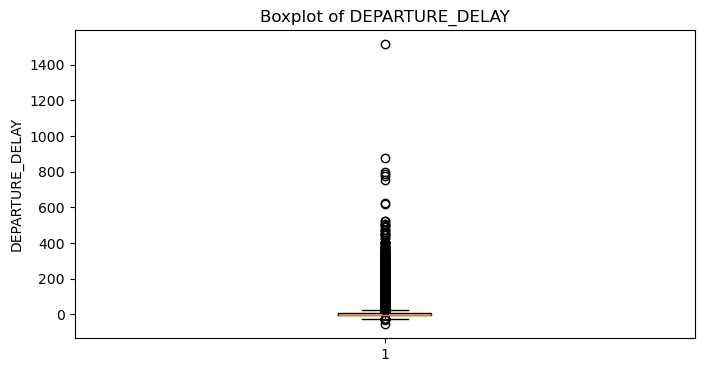

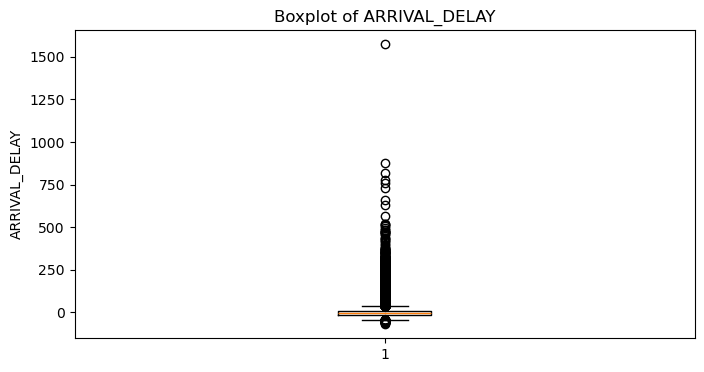

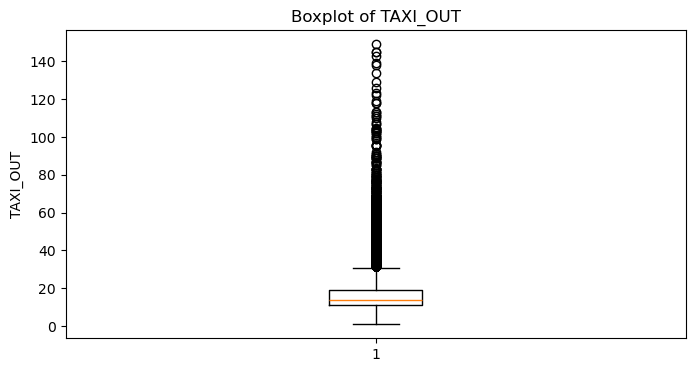

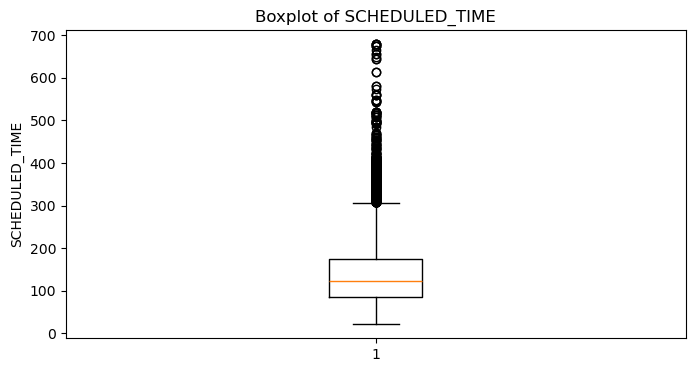

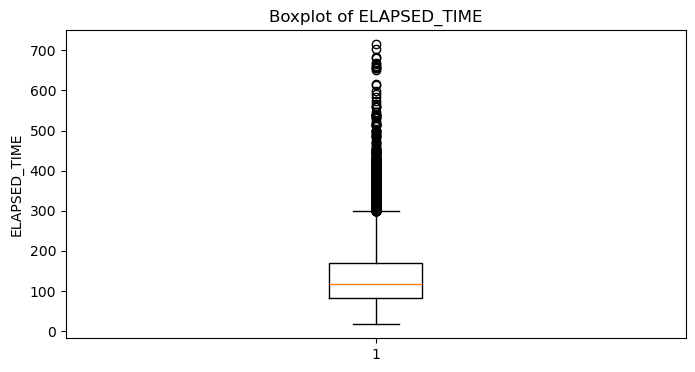

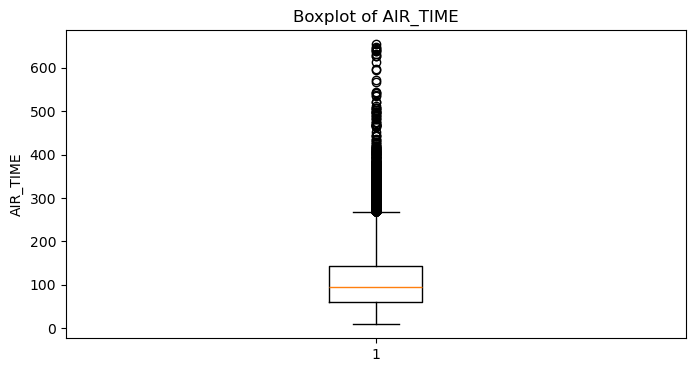

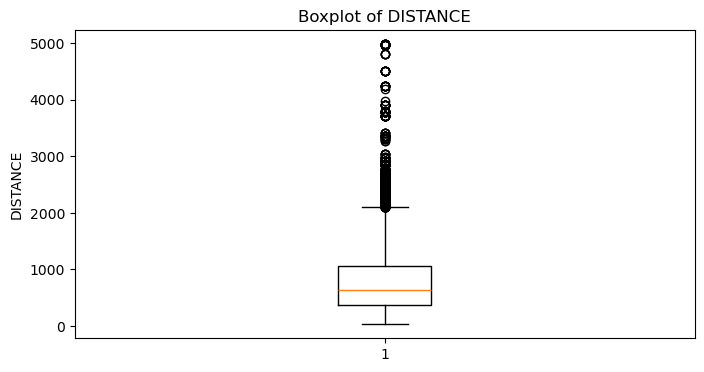

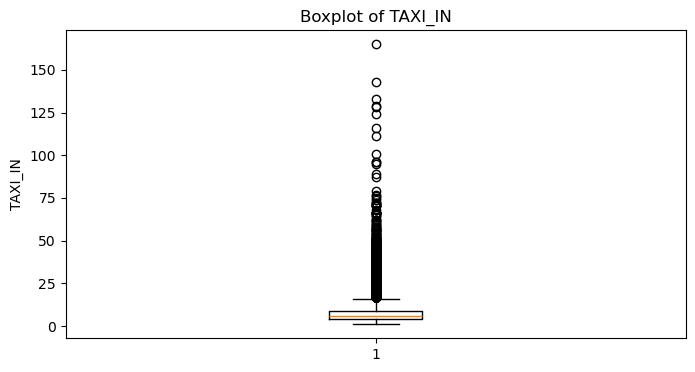

In [105]:
import matplotlib.pyplot as plt

for col in outlier_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

### Outlier Observations

### Outlier Observations

#### 1.The IQR method and boxplots identified potential extreme values in several flight-operation variables.
#### 2.Higher values in DEPARTURE_DELAY and ARRIVAL_DELAY indicate flights experiencing significant delays.
#### 3.Higher values in DISTANCE, AIR_TIME, ELAPSED_TIME, and SCHEDULED_TIME can represent long-distance or long-duration flights.
#### 4.Higher TAXI_OUT and TAXI_IN values can represent genuine airport operational conditions.
#### 5.Therefore, the identified extreme values were considered meaningful flight-operation observations.

### Outlier Treatment — Retain

#### 1.The identified outliers are retained because they represent genuine variations in flight operations.
#### 2.Extreme values in delay, distance, flight duration, and taxi times can provide valuable information about real-world flight performance.
#### 3.Therefore, the identified outliers are retained in the dataset for further analysis.

### Final Dataset

In [106]:
df_clean = df.copy()
print("Original dataset shape:", df.shape)
print("Final dataset shape:", df_clean.shape)

Original dataset shape: (50000, 31)
Final dataset shape: (50000, 31)


## ▸Remove

In [107]:
# Create an outlier mask

outlier_mask = (
    (df[outlier_cols] < lower_bound) |
    (df[outlier_cols] > upper_bound)
).any(axis=1)

# Count outlier records

outlier_record_count = outlier_mask.sum()

print("Number of outlier records:", outlier_record_count)

Number of outlier records: 12675


### Remove the identified outlier records

In [108]:
# Retain all observations after outlier analysis

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Final dataset shape:", df_clean.shape)

Original dataset shape: (50000, 31)
Final dataset shape: (50000, 31)


### Check how many records were removed

In [109]:
rows_removed = len(df) - len(df_clean)

print("Rows removed:", rows_removed)

Rows removed: 0


### Check the final dataset

In [110]:
df_clean.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,5,14,4,US,1721,N174US,CLT,SMF,1810,...,2043.0,4.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
1,2015,11,29,7,MQ,3363,N902MQ,LEX,ORD,1837,...,1942.0,17.0,0,0,Not Cancelled,0.0,0.0,0.0,17.0,0.0
2,2015,2,10,2,US,1933,N562UW,PHL,ORD,730,...,834.0,-28.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
3,2015,12,21,1,UA,1929,N460UA,SEA,EWR,622,...,1414.0,-17.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
4,2015,5,7,4,DL,1478,N67171,ATL,PHL,725,...,920.0,-5.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0


### Conclusion – Outlier Analysis
#### 1. The IQR method was used to identify potential outliers in selected flight-operation variables.
#### 2. Boxplots were used to visually examine extreme values.
#### 3. Potential outliers were observed in variables such as departure delay, arrival delay, distance, and flight duration.
#### 4. These extreme values can represent genuine flight-operation conditions.
#### 5. Therefore, the identified outliers were retained in the dataset.
#### 6. The final dataset contains 50,000 rows and 31 columns and is ready for further validation and analysis.

## ▸Transform

### Outlier Treatment – Transform
#### 1.Transformation can be used when extreme values significantly affect the distribution of a numerical variable.
#### 2.For flight-delay data, a transformation such as the logarithmic transformation can help reduce the effect of highly skewed positive delay 
#### values while preserving the observations.
#### 3.However, because flight delays can also contain negative values, the transformation must be applied carefully.

In [111]:
df_clean.drop(
    columns=['DEPARTURE_DELAY_TRANSFORMED'],
    inplace=True
)

KeyError: "['DEPARTURE_DELAY_TRANSFORMED'] not found in axis"

In [ ]:
print("Final dataset shape:", df_clean.shape)

In [ ]:
df_clean = df.copy()

In [ ]:
print(df_clean.shape)

# 6. Data Validation

## ▸Contains valid data

### 1. Check MONTH

In [ ]:
print("Invalid MONTH values:",
      (~df_clean['MONTH'].between(1, 12)).sum())

#### - MONTH values were checked to ensure they fall between 1 and 12.
#### - No invalid MONTH values were identified.
#### - The validation result was 0 invalid values, confirming that the MONTH column contains valid values.

### 2. Check DAY_OF_WEEK

In [112]:
print("Invalid DAY_OF_WEEK values:",
      (~df_clean['DAY_OF_WEEK'].between(1, 7)).sum())

Invalid DAY_OF_WEEK values: 0


#### - DAY_OF_WEEK values were checked to ensure they fall between 1 and 7.
#### - No invalid DAY_OF_WEEK values were identified.
#### - The validation result was 0 invalid values, confirming that the column contains valid weekday values.

### 3. Check DAY

In [113]:
print("Invalid DAY values:",
      (~df_clean['DAY'].between(1, 31)).sum())

Invalid DAY values: 0


#### - DAY values were checked to ensure they fall between 1 and 31.
#### - No invalid DAY values were identified.
#### - The validation result was 0 invalid values, confirming that the DAY column contains valid values.

### 4. Check DISTANCE

In [114]:
print("Invalid DISTANCE values:",
      (df_clean['DISTANCE'] <= 0).sum())

Invalid DISTANCE values: 0


#### - DISTANCE values were checked to ensure they are greater than zero.
#### - No zero or negative DISTANCE values were identified.
#### - The validation result was 0 invalid values, confirming that the distance values are valid.

### 5. Check SCHEDULED_TIME

In [115]:
print("Invalid SCHEDULED_TIME values:",
      (df_clean['SCHEDULED_TIME'] <= 0).sum())

Invalid SCHEDULED_TIME values: 0


#### - SCHEDULED_TIME values were checked to ensure they are greater than zero.
#### - No zero or negative scheduled-time values were identified.
#### - The validation result was 0 invalid values, confirming that the scheduled-time values are valid.

### 6. Check CANCELLED

In [116]:
print("Invalid CANCELLED values:",
      (~df_clean['CANCELLED'].isin([0, 1])).sum())

Invalid CANCELLED values: 0


#### - CANCELLED values were checked for valid binary values.
#### - The column contains only the expected values 0 and 1.
#### - The validation result was 0 invalid values, confirming that the CANCELLED column is valid.

### 7. Check DIVERTED

In [117]:
print("Invalid DIVERTED values:",
      (~df_clean['DIVERTED'].isin([0, 1])).sum())

Invalid DIVERTED values: 0


#### - DIVERTED values were checked for valid binary values.
#### - The column contains only the expected values 0 and 1.
#### - The validation result was 0 invalid values, confirming that the DIVERTED column is valid.

## ▸Has appropriate data types

### Display Data Types

#### - The dataset contains **31 columns**, with numerical and categorical variables represented using appropriate data types.
#### - Columns such as `YEAR`, `MONTH`, `DAY`, `DAY_OF_WEEK`, `FLIGHT_NUMBER`, and `DISTANCE` are stored as `int64`, which is suitable for their 
#### numerical values.
#### - Continuous operational variables such as `DEPARTURE_DELAY`, `ARRIVAL_DELAY`, `TAXI_OUT`, `AIR_TIME`, and `DISTANCE` are represented 
#### using numerical data types.
#### - Categorical variables such as `AIRLINE`, `TAIL_NUMBER`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, and `CANCELLATION_REASON` are 
#### stored as `object`.
#### - Overall, the displayed data types are appropriate for performing further analysis on the flight dataset.

### Get a Clear Data-Type Summary

In [119]:
data_type_summary = pd.DataFrame({
    'Column': df_clean.columns,
    'Data Type': df_clean.dtypes.values
})

data_type_summary

,Column,Data Type
0,YEAR,int64
1,MONTH,int64
2,DAY,int64
3,DAY_OF_WEEK,int64
4,AIRLINE,object
5,FLIGHT_NUMBER,int64
6,TAIL_NUMBER,object
7,ORIGIN_AIRPORT,object
8,DESTINATION_AIRPORT,object
9,SCHEDULED_DEPARTURE,int64


#### - The dataset contains **31 columns**, covering flight details, timing information, delays, and operational information.
#### - Integer data types (`int64`) are used for variables such as `YEAR`, `MONTH`, `DAY`, `DAY_OF_WEEK`, `FLIGHT_NUMBER`, `DISTANCE`, 
#### `DIVERTED`and `CANCELLED`.
#### - Floating-point data types (`float64`) are used for variables such as `DEPARTURE_DELAY`, `ARRIVAL_DELAY`, `TAXI_OUT`, `AIR_TIME`,
#### `ELAPSED_TIME`, and other timing and delay-related variables.
#### - Object data types are used for categorical variables such as `AIRLINE`, `TAIL_NUMBER`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, and
#### `CANCELLATION_REASON`.
#### - The data type summary confirms that the columns are represented using suitable numerical and categorical data types for further 
#### analysis.

### Check Numeric Columns

In [120]:
numeric_columns = df_clean.select_dtypes(
    include=['int64', 'float64']
).columns

print("Number of numerical columns:", len(numeric_columns))
print("\nNumerical columns:")
print(list(numeric_columns))

Number of numerical columns: 26

Numerical columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'FLIGHT_NUMBER', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']


#### - The dataset contains **26 numerical columns**.
#### - These columns include flight dates, flight numbers, scheduled and actual timings, delays, distances, and operational indicators.
#### - Variables such as `DEPARTURE_DELAY`, `ARRIVAL_DELAY`, `TAXI_OUT`, `AIR_TIME`, and `DISTANCE` are appropriately represented as
#### numerical data.
#### - Integer variables such as `YEAR`, `MONTH`, `DAY`, `DAY_OF_WEEK`, and `FLIGHT_NUMBER` are suitable for numerical analysis.
#### - The identified numerical columns are appropriate for statistical calculations and further analysis.

### Check Categorical Columns

In [121]:
categorical_columns = df_clean.select_dtypes(
    include=['object']
).columns

print("Number of categorical columns:", len(categorical_columns))
print("\nCategorical columns:")
print(list(categorical_columns))

Number of categorical columns: 5

Categorical columns:
['AIRLINE', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON']


### Categorical Columns Validation
#### - The dataset contains **5 categorical columns**.
#### - `AIRLINE` represents the airline operating the flight and is appropriately treated as a categorical variable.
#### - `TAIL_NUMBER`, `ORIGIN_AIRPORT`, and `DESTINATION_AIRPORT` contain identification and airport information and are treated as 
#### categorical variables.
#### - `CANCELLATION_REASON` represents the reason associated with cancelled flights and is also categorical.
#### - The identified categorical columns are appropriately represented as `object` data types and are suitable for categorical analysis.

### Check for Unwanted Data Types

In [123]:
object_columns = df_clean.select_dtypes(
    include=['object']
).columns

print("Categorical/Object columns:")
print(list(object_columns))

Categorical/Object columns:
['AIRLINE', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON']


#### - The dataset contains **5 columns with object data types**.
#### - These columns are `AIRLINE`, `TAIL_NUMBER`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, and `CANCELLATION_REASON`.
#### - All five object-type columns represent categorical or identification information.
#### - No numerical flight-operation column was identified as an unwanted object data type.
#### - Therefore, no unnecessary data type conversions were required, and the current data types are suitable for further analysis.

## ▸Is free from unnecessary inconsistencies


### Check Airline Values

In [124]:
print("Airline values:")
print(sorted(df_clean['AIRLINE'].dropna().unique()))

Airline values:
['AA', 'AS', 'B6', 'DL', 'EV', 'F9', 'HA', 'MQ', 'NK', 'OO', 'UA', 'US', 'VX', 'WN']


#### - The `AIRLINE` column was checked for unique values and inconsistent representations.
#### - A total of **14 unique airline codes** were identified.
#### - All airline values follow a consistent two-letter code format, such as `AA`, `DL`, `UA`, and `WN`.
#### - No unnecessary differences in capitalization, spacing, or formatting were observed in the airline codes.
#### - Therefore, the `AIRLINE` column is consistent and does not require further cleaning.

### Check Cancellation Reason

In [125]:
print("Cancellation Reason values:")
print(df_clean['CANCELLATION_REASON'].value_counts(dropna=False))

Cancellation Reason values:
CANCELLATION_REASON
Not Cancelled    49206
B                  432
A                  215
C                  146
D                    1
Name: count, dtype: int64


#### - The `CANCELLATION_REASON` column was checked for unique values and consistency.
#### - The column contains five categories: `Not Cancelled`, `A`, `B`, `C`, and `D`.
#### - The `Not Cancelled` category is the most frequent value, with 49,206 records.
#### - The cancellation reason codes `A`, `B`, `C`, and `D` are consistently represented using single-letter codes.
#### - No unnecessary spacing, capitalization, or formatting inconsistencies were observed in the displayed values.

### Check Airport Codes

In [126]:
print("Origin Airport sample values:")
print(sorted(df_clean['ORIGIN_AIRPORT'].dropna().unique())[:30])

print("\nDestination Airport sample values:")
print(sorted(df_clean['DESTINATION_AIRPORT'].dropna().unique())[:30])

Origin Airport sample values:
['10135', '10140', '10155', '10157', '10158', '10185', '10208', '10257', '10268', '10279', '10299', '10397', '10408', '10423', '10431', '10434', '10529', '10561', '10577', '10599', '10620', '10627', '10631', '10693', '10713', '10721', '10728', '10731', '10732', '10739']

Destination Airport sample values:
['10136', '10140', '10141', '10146', '10155', '10157', '10158', '10185', '10208', '10257', '10279', '10299', '10372', '10397', '10408', '10423', '10431', '10434', '10529', '10561', '10577', '10599', '10620', '10627', '10693', '10713', '10721', '10731', '10732', '10747']


#### - The `ORIGIN_AIRPORT` and `DESTINATION_AIRPORT` columns were checked for consistency in their categorical values.
#### - The displayed airport values follow a consistent format, with airport identifiers represented as codes such as `10135`, `10140`, and 
#### `10397`.
#### - Both origin and destination airport columns contain consistently formatted airport identifiers in the sampled values.
#### - No obvious spacing or capitalization inconsistencies were observed in the displayed sample values.
#### - The airport columns can therefore be treated as categorical identifiers for further analysis.

### Check for leading/trailing spaces

In [127]:
print("Origin airport values with leading/trailing spaces:",
      (df_clean['ORIGIN_AIRPORT'] != df_clean['ORIGIN_AIRPORT'].str.strip()).sum())

print("Destination airport values with leading/trailing spaces:",
      (df_clean['DESTINATION_AIRPORT'] != df_clean['DESTINATION_AIRPORT'].str.strip()).sum())

Origin airport values with leading/trailing spaces: 0
Destination airport values with leading/trailing spaces: 0


#### - The `ORIGIN_AIRPORT` column was checked for leading and trailing spaces.
#### - The `DESTINATION_AIRPORT` column was also checked for leading and trailing spaces.
#### - Both columns returned **0 inconsistent values**.
#### - This confirms that the airport identifiers do not contain unnecessary spaces.
#### - Therefore, no whitespace cleaning is required for the airport columns.

## ▸Is ready for analysis

### Check final shape

In [128]:
print("Final dataset shape:", df_clean.shape)

Final dataset shape: (50000, 31)


#### - The final dataset contains **50,000 rows** and **31 columns**.
#### - The expected number of columns has been maintained after the validation process.
#### - No additional unnecessary columns are present in the final dataset.
#### - The dataset size is sufficient to proceed with further flight-operation analysis.

### Check duplicate records

In [129]:
print("Duplicate records:", df_clean.duplicated().sum())

Duplicate records: 0


#### - The final dataset was checked for duplicate records.
#### - The validation result shows **0 duplicate records**.
#### - This confirms that no exact duplicate rows are present in the final dataset.
#### - Therefore, no additional duplicate removal is required.

### Check column count

In [130]:
print("Number of columns:", len(df_clean.columns))

Number of columns: 31


#### - The final dataset contains **31 columns**.
#### - The column count is consistent with the original dataset structure.
#### - No unnecessary columns were added during the validation process.
#### - The 31 columns provide the required flight, timing, airport, delay, and cancellation information for further analysis.

### Check final dataset preview

In [131]:
df_clean.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,5,14,4,US,1721,N174US,CLT,SMF,1810,...,2043.0,4.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
1,2015,11,29,7,MQ,3363,N902MQ,LEX,ORD,1837,...,1942.0,17.0,0,0,Not Cancelled,0.0,0.0,0.0,17.0,0.0
2,2015,2,10,2,US,1933,N562UW,PHL,ORD,730,...,834.0,-28.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
3,2015,12,21,1,UA,1929,N460UA,SEA,EWR,622,...,1414.0,-17.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0
4,2015,5,7,4,DL,1478,N67171,ATL,PHL,725,...,920.0,-5.0,0,0,Not Cancelled,0.0,0.0,0.0,0.0,0.0


#### - The final dataset contains **50,000 rows**, confirming that the dataset is not empty.
#### - A preview of the final dataset confirms that the flight records and their corresponding features are available.
#### - The dataset maintains its **31-column structure** after the validation process.
#### - Based on the validation checks performed, the dataset is ready for further analysis.

### Check whether the dataset is empty

In [132]:
print("Number of rows:", len(df_clean))
print("Dataset is empty:", df_clean.empty)

Number of rows: 50000
Dataset is empty: False


## 7. Initial Business Observations

### Write your initial observations regarding airlines, airports, delays, cancellations, and flight operations before 
### beginning detailed analysis.


#### - The dataset contains flight information from multiple airlines, with details about scheduled operations, actual timings, airports, delays, 
#### cancellations, and diversions.
#### - Multiple airlines and airport combinations are present, indicating that the dataset can be used to study airline-level and route-level  

#### flight operations.
#### - The dataset contains both positive and negative `ARRIVAL_DELAY` values. Positive values indicate delayed arrivals, while negative values 
#### indicate flights that arrived earlier than scheduled.
#### - Cancellation information is available through the `CANCELLED` and `CANCELLATION_REASON` columns, allowing cancellation patterns to 
####  be examined in further analysis.
#### - Different delay categories such as `AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, and 
#### `WEATHER_DELAY` are available, which can help identify major causes of flight delays.
#### - Operational variables such as `TAXI_OUT`, `TAXI_IN`, `AIR_TIME`, `ELAPSED_TIME`, and `DISTANCE` provide useful information for 

#### understanding flight performance and operational efficiency.
#### - The dataset contains 50,000 flight records and 31 features, providing sufficient information for detailed analysis of delays, cancellations, 

#### airlines, airports, and flight operations.

In [133]:
# Save the cleaned dataset as CSV

df_clean.to_csv("cleaned_flight_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
